#### Question 5: Interpolation of latent variables with optimal beta = 0.1

In [1]:
import os
import tqdm
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.utils import save_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Data loading
path = os.path.join(os.getcwd(), 'data','butterfly')

MEAN = torch.tensor([0.47998455, 0.46537864, 0.33653912]) # After Calculation, Mean is directly given to the code.
STD = torch.tensor([0.22608626, 0.22103393, 0.21348171])

image_size = 128
batch_size = 128
workers = 8
n_channels = 3
latent_dim = 128
lr = 0.0002
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_data = ImageFolder(path, transform=transform)
loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=workers)

classes = train_data.classes

In [13]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim

        self.input_dim = n_channels
        self.output_dim = latent_dim  
        self.encode = nn.Sequential(
            nn.Conv2d(self.input_dim, 8, 4, 2, 1, bias=False), # 64 x 64
            nn.BatchNorm2d(8),
            nn.LeakyReLU(0.2),

            nn.Conv2d(8, 16, 4, 2, 1, bias=False), # 32 x 32
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),

            nn.Conv2d(16, 32, 4, 2, 1, bias=False), # 16 x 16
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 4, 2, 1, bias=False), # 8 x 8
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # 4 x 4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False), # 2 x 2
            nn.BatchNorm2d(256),
            

        )
        self.layer_mean = nn.Linear(256*2*2, self.output_dim)
        self.layer_var = nn.Linear(256*2*2, self.output_dim)
    def forward(self, x):
        x = self.encode(x)
        x = torch.flatten(x, start_dim=1)
        mean = self.layer_mean(x)
        var = self.layer_var(x)
        return mean, var
    
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.batch_size = batch_size
        self.latent_dim = latent_dim

        self.input_dim = latent_dim
        self.output_dim = n_channels

        self.fc = nn.Linear(self.input_dim, self.input_dim*2*2)
        
        self.decode = nn.Sequential(

            nn.ConvTranspose2d(self.input_dim, 128, 4, 2, 1, bias=False),  #  4 x 4
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  #  8 x 8
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),    # 16 x 16
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1, bias=False),    # 32 x 32
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.ConvTranspose2d(16, 8, 4, 2, 1, bias=False),     # 64 x 64
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(8, self.output_dim, 4, 2, 1, bias=False), # 128 x 128
            
            nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), self.latent_dim,2,2)
        out = self.decode(x)
        return out
    
class Vanilla_VAE(nn.Module):
    def __init__(self):
        super(Vanilla_VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterization(self, mean, var):
        std = torch.exp(0.5*var) # standard deviation from log(variance)
        epsilon = torch.randn_like(std) # sampling from normal (0,1)
        return mean + std * epsilon
    
    def forward(self, x):
        mean, log_var = self.encoder(x)
        z = self.reparameterization(mean, log_var)
        x_hat = self.decoder(z) # reconstructed image
        return x_hat, mean, log_var
            
    def sample(self, z):
        return self.decoder(z)
    
def weights_init(c):
    class_name = c.__class__.__name__
    if class_name.find("Conv") != -1:
        nn.init.normal_(c.weight.data, 0.0, 0.02)
        # mean of Conv layer weights is taken 0.0
    elif class_name.find("BatchNorm") != -1:
        nn.init.normal_(c.weight.data, 1.0, 0.0)
        # mean of Batch Normalization layer weights is taken 0.0
        nn.init.constant_(c.bias.data, 0)
def read_epoch_count(file_path):
    with open(file_path, 'r') as file:
        return int(file.readline().strip())

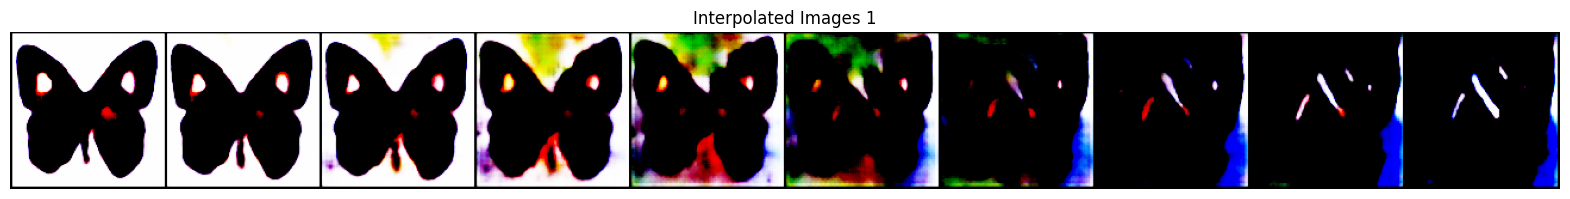

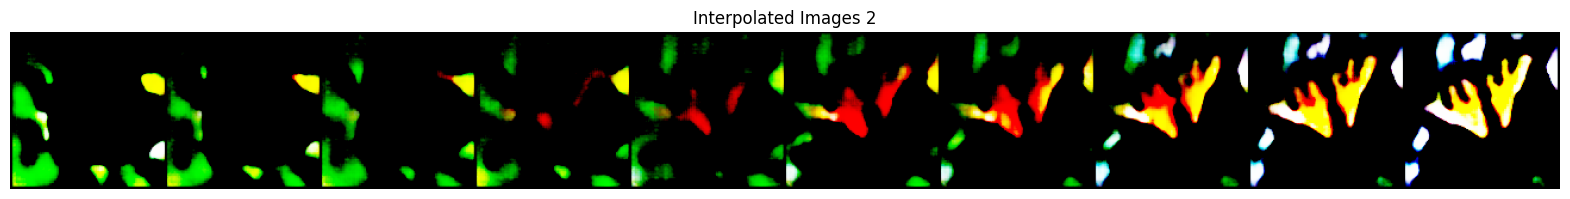

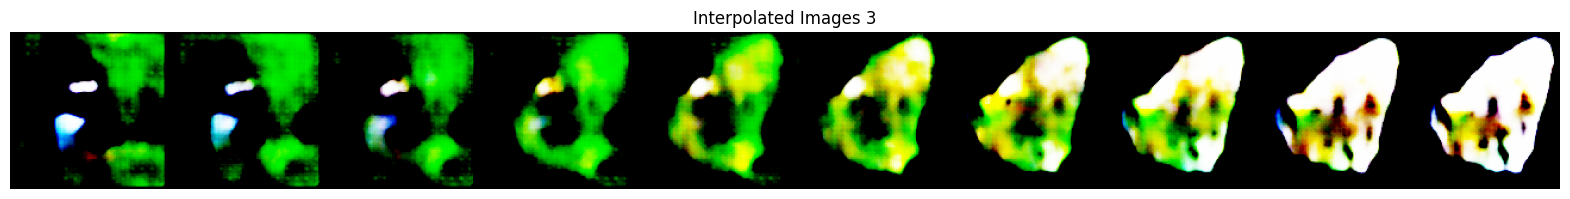

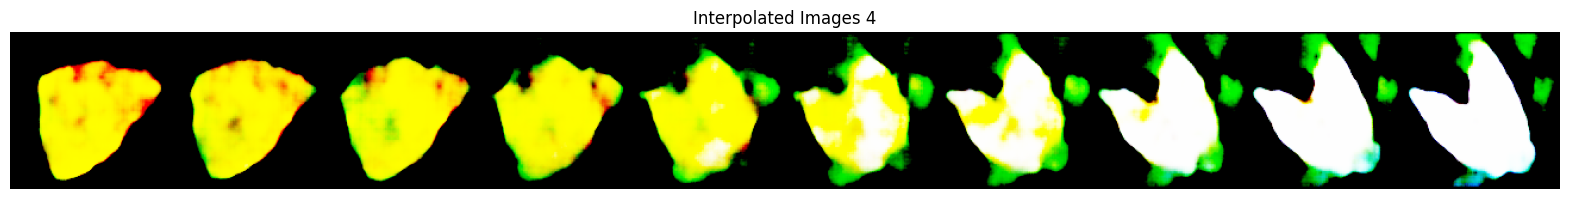

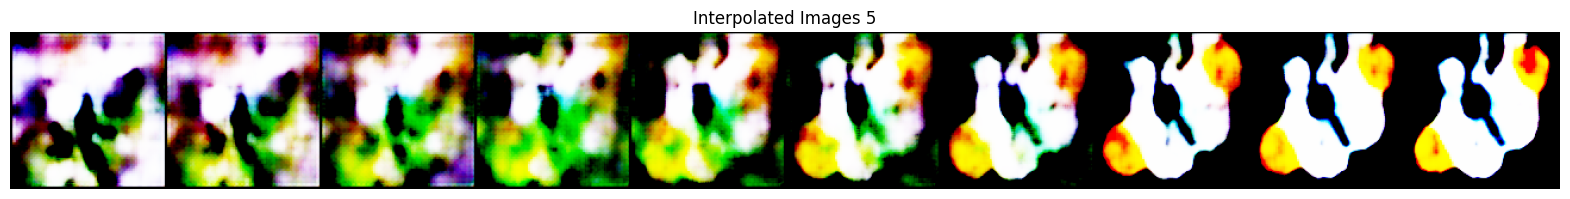

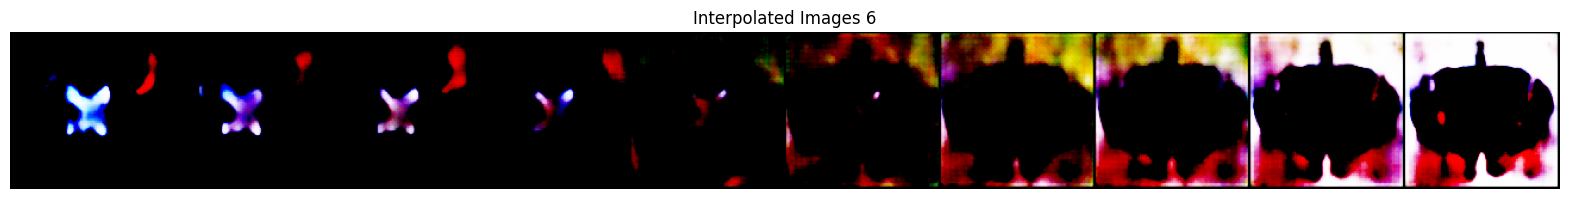

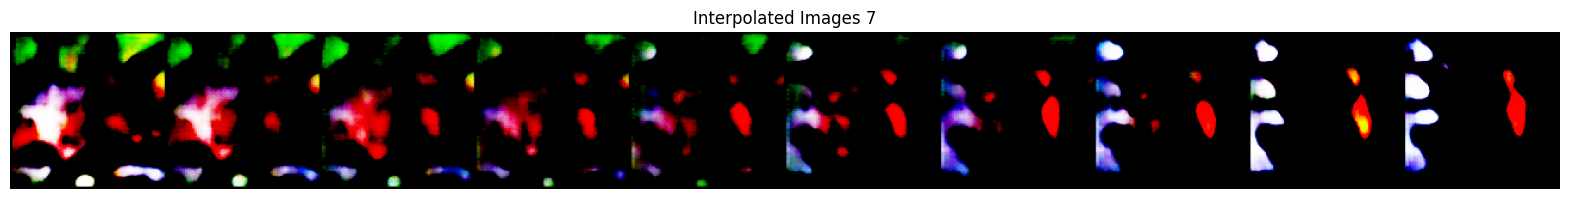

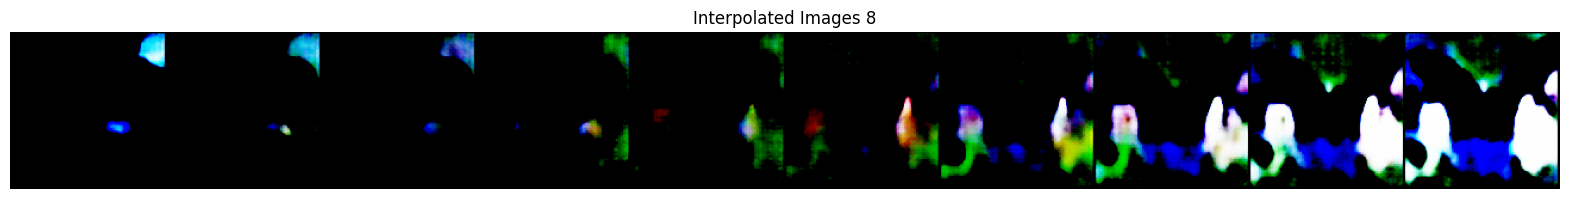

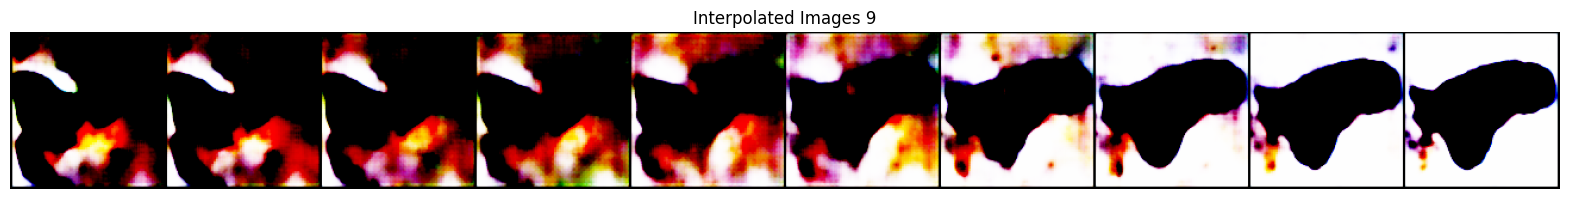

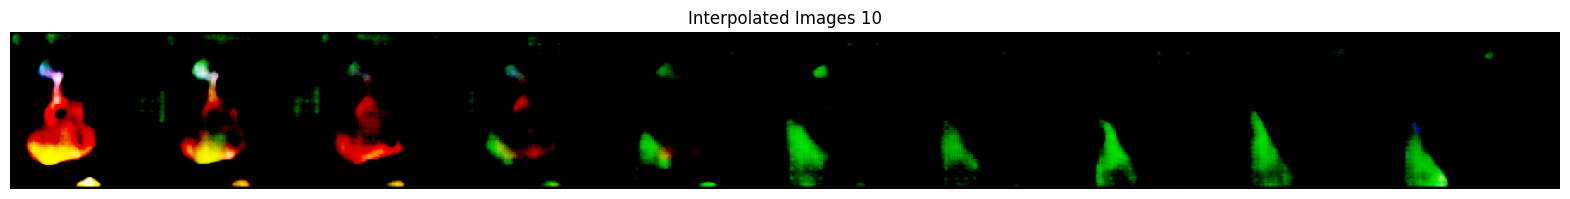

In [17]:
# path = os.path.join(os.getcwd(), 'vanilla_vae_z128_newloss.pth')
path = os.path.join(os.getcwd(), 'output/beta_vae0_01.pth')
vae = torch.load(path, weights_only=False).to(device)
vae.eval()
loader = DataLoader(train_data, batch_size=1, shuffle=True, num_workers=workers)
with torch.no_grad():
    for i, (img1, img2) in enumerate(zip(loader, loader)):
        if i >= 10:
            break
        img = []
        img1 = img1[0].to(device)  # Assuming loader returns a tuple (image, label)
        img2 = img2[0].to(device)
        
        mean1,log_var1 = vae.encoder(img1)
        mean2,log_var2 = vae.encoder(img2)
        
        for j, alpha in enumerate(np.linspace(0, 1, num=10)):
            
            z1 = vae.reparameterization(mean1, log_var1)
            z2 = vae.reparameterization(mean2, log_var2)

            z = alpha * z1 + (1 - alpha) * z2
            sample = vae.decoder(z).cpu()
            img.append(sample)
        
        img = torch.cat(img, dim=0)
        plt.figure(figsize=(20, 5))
        plt.axis("off")
        plt.title(f"Interpolated Images {i+1}")
        plt.imshow(make_grid(img.clamp(0,1), nrow=10).permute(1, 2, 0).numpy())
        plt.show()